In [2]:
import requests
import pandas as pd

api_key = 
base_url = "https://api.polygon.io/v2/reference/news"

params = {
    "apiKey": api_key,
    "q": "tariff",
    "sort": "published_utc",
    "order": "asc",
    "limit": 1000,
    "published_utc.gte": "2024-12-15"
}

results = []
response = requests.get(base_url, params=params)
data = response.json()
results.extend(data.get("results", []))

# Handle pagination
while 'next_url' in data:
    response = requests.get(data['next_url'], params={"apiKey": api_key})
    data = response.json()
    results.extend(data.get("results", []))

# Save to CSV
df = pd.DataFrame(results)
df = df[['published_utc', 'title', 'description', 'publisher']]
df.to_csv("tariff_news_2025.csv", index=False)

print(f"Saved {len(df)} news items from Dec 15, 2024 to present.")

Saved 22086 news items from Dec 15, 2024 to present.


In [3]:
import pandas as pd

# Filter down from 22K
df = pd.read_csv("tariff_news_2025.csv")

signal_keywords = [
    'tariff', 'duties', 'levy', 'impose', 'pause', 'cancel', 'exemption', 'section 301',
    'trade war', 'negotiation', 'negotiate', 'sanction', 'deal', 'talks', 'stall', 'tumble', 'rebound',
    'retaliation', 'escalate', 'escalation', 'relief', 'uncertainty', 'outlook', 'supply chain',
    'executive order', 'trade agreement', 'fta', 'ustr', 'wto', 'adjust', 'hike', 'suspend',
    'rollback', 'import', 'export', 'quota'
]

df_filtered = df[df['title'].str.lower().str.contains('|'.join(signal_keywords), na=False)].copy()
print(f"Filtered down to {len(df_filtered)} headlines.")

Filtered down to 2336 headlines.


In [4]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Extend base stopwords
custom_stopwords = stop_words.union({
    "2025", "stock", "stocks", "market", "quarter", "buy", "inc", "class", "action", 
    "securities", "announces", "company", "financial", "firm", "share", "shares",
    "news", "report", "announced", "release", "press", "statement", "lawsuit", 
    "counsel", "deadline"
})

# Clean + tokenize
def preprocess(text):
    text = re.sub(r'\W+', ' ', str(text).lower())
    tokens = [word for word in text.split() if word not in custom_stopwords and len(word) > 2]
    return tokens

df_filtered['tokens'] = df_filtered['title'].apply(preprocess)
texts = df_filtered['tokens'].tolist()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/johngrier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
from gensim import corpora, models

# Create dictionary + corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Fit LDA
lda_model = models.LdaModel(corpus, num_topics=2, id2word=dictionary, passes=10, random_state=42)

# Print topic keywords
for idx, topic in lda_model.print_topics(num_words=6):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.063*"investors" + 0.058*"important" + 0.055*"rosen" + 0.055*"encourages" + 0.055*"secure" + 0.029*"investor"
Topic 1: 0.018*"tariffs" + 0.017*"tariff" + 0.013*"industry" + 0.012*"outlook" + 0.011*"trump" + 0.010*"growth"


In [6]:
# Define seed topics
topic_0_words = ["impose", "tariff", "levy", "duties", "increase", "announce"]
topic_1_words = ["pause", "cancel", "lift", "exempt", "relief", "deal", "talks"]

# Create synthetic documents to guide LDA
fake_docs = [' '.join(topic_0_words)] * 5 + [' '.join(topic_1_words)] * 5
n_fake = len(fake_docs)

# Combine with the real news titles
all_docs = fake_docs + df['title'].tolist()

# Preprocess all documents
texts = [preprocess(doc) for doc in all_docs]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Fit seeded LDA
lda_model2 = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=2,
    passes=25,
    random_state=42
)

# Inspect topics
for idx, topic in lda_model2.print_topics(num_words=6):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.012*"dividend" + 0.007*"growth" + 0.007*"today" + 0.006*"billion" + 0.006*"right" + 0.006*"could"
Topic 1: 0.041*"investors" + 0.017*"results" + 0.016*"investor" + 0.015*"alert" + 0.015*"first" + 0.013*"losses"


In [11]:
from gensim import corpora, models
import time

# Use expanded stopword list
custom_stopwords = stop_words.union({
    "2025", "stock", "stocks", "market", "quarter", "buy", "inc", "class", "action", 
    "securities", "announces", "company", "financial", "firm", "share", "shares",
    "news", "report", "announced", "release", "press", "statement", "lawsuit", 
    "counsel", "deadline", "rosen", "alert", "lead", "investors", "investor", "contact"
})

def preprocess_hdp(text):
    text = re.sub(r'\W+', ' ', str(text).lower())
    tokens = [word for word in text.split() if word not in custom_stopwords and len(word) > 2]
    return tokens
    
# dictionary + corpus
texts_hdp = df_filtered['title'].apply(preprocess_hdp).tolist()
dictionary_hdp = corpora.Dictionary(texts_hdp)
corpus_hdp = [dictionary_hdp.doc2bow(text) for text in texts_hdp]

# Fit
hdp_model = models.HdpModel(corpus=corpus_hdp, id2word=dictionary_hdp)
print(f"HDP model trained in {time.time() - start_time:.2f} seconds\n")

# View topics
for idx, topic in hdp_model.print_topics(num_topics=25, num_words=8):
    print(f"HDP Topic {idx}: {topic}")

HDP model trained in 202.80 seconds

HDP Topic 0: 0.006*important + 0.005*encourages + 0.005*secure + 0.002*leading + 0.002*excess + 0.002*recognized + 0.002*lineage + 0.002*losses
HDP Topic 1: 0.002*two + 0.002*important + 0.002*encourages + 0.002*secure + 0.002*articul8 + 0.002*hpe + 0.001*cagr + 0.001*per
HDP Topic 2: 0.002*encourages + 0.002*important + 0.002*secure + 0.002*optimism + 0.002*russian + 0.001*lyle + 0.001*icon + 0.001*despegar
HDP Topic 3: 0.002*important + 0.002*secure + 0.002*encourages + 0.002*studies + 0.002*vanilla + 0.001*vehicles + 0.001*chief + 0.001*chine
HDP Topic 4: 0.005*secure + 0.005*important + 0.005*encourages + 0.003*leading + 0.002*law + 0.002*automakers + 0.002*agents + 0.002*275
HDP Topic 5: 0.002*important + 0.002*wiz + 0.002*rain + 0.002*encourages + 0.001*adobe + 0.001*subscription + 0.001*units + 0.001*crocs
HDP Topic 6: 0.002*free + 0.002*caution + 0.002*popular + 0.002*edition + 0.002*nodigt + 0.001*bode + 0.001*pushing + 0.001*cement
HDP Top

In [12]:
from gensim.models import CoherenceModel

# Default LDA
coherence_default = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

# Seeded LDA
coherence_seeded = CoherenceModel(
    model=lda_model2,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

# HDP
coherence_hdp = CoherenceModel(
    model=hdp_model,
    texts=texts_hdp,  # use your HDP-specific preprocessed text
    dictionary=dictionary_hdp,
    coherence='c_v'
).get_coherence()

# Print results
print(f"Coherence - Default LDA: {coherence_default:.4f}")
print(f"Coherence - Seeded LDA : {coherence_seeded:.4f}")
print(f"Coherence - HDP        : {coherence_hdp:.4f}")

Coherence - Default LDA: 0.6363
Coherence - Seeded LDA : 0.3391
Coherence - HDP        : 0.7598


In [13]:
from collections import defaultdict
import pandas as pd

# Get topic distributions for each document
topic_counts = defaultdict(int)
topic_series = []

for doc_bow in corpus_hdp:
    topic_dist = hdp_model[doc_bow]
    if topic_dist:
        top_topic = max(topic_dist, key=lambda x: x[1])[0]
        topic_series.append(top_topic)
    else:
        topic_series.append(-1)

# Add to df
df_filtered['hdp_top_topic'] = topic_series
df_filtered['date'] = pd.to_datetime(df_filtered['published_utc']).dt.date

# Count topics per day
topic_time = df_filtered.groupby(['date', 'hdp_top_topic']).size().unstack(fill_value=0)
topic_time = topic_time.sort_index()

In [16]:
import requests
import pandas as pd
from datetime import datetime

api_key =  

# Load S&P 500 tickers (from Wikipedia)
wiki_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
sp500_df = pd.read_html(wiki_url)[0]
sp500_tickers = [ticker.replace('.', '-') for ticker in sp500_df['Symbol'].tolist()]

# Add relevant ETFs
etf_tickers = ['SPY', 'XLI', 'CARZ', 'FXI', 'XRT', 'SMH']
all_tickers = sp500_tickers + etf_tickers

# Define date range
start_date = "2024-12-15"
end_date = "2025-05-10"

# Function to fetch returns from Polygon
def fetch_stock_returns(ticker):
    url = f"https://api.polygon.io/v2/aggs/ticker/{ticker}/range/1/day/{start_date}/{end_date}"
    params = {
        "adjusted": "true",
        "sort": "asc",
        "apiKey": api_key
    }
    try:
        r = requests.get(url, params=params)
        results = r.json().get("results", [])
        df = pd.DataFrame(results)
        df['date'] = pd.to_datetime(df['t'], unit='ms').dt.date
        df['return'] = df['c'].pct_change()
        return df[['date', 'return']].dropna().rename(columns={"return": ticker})
    except Exception as e:
        print(f"Failed for {ticker}: {e}")
        return pd.DataFrame()

# Pull and merge all returns
returns_df = None
for ticker in all_tickers:
    df = fetch_stock_returns(ticker)
    if df.empty:
        continue
    if returns_df is None:
        returns_df = df
    else:
        returns_df = returns_df.merge(df, on='date', how='outer')

Failed for BRK-B: 't'
Failed for BF-B: 't'


In [18]:
manual_tickers = ['BRK.B', 'BF.B']
manual_returns = []

for ticker in manual_tickers:
    df = fetch_stock_returns(ticker)
    if not df.empty:
        manual_returns.append(df.set_index('date'))

# Merge back manually
for i, df in enumerate(manual_returns):
    returns_df = returns_df.merge(df, on='date', how='outer')

In [19]:
returns_df.to_csv("sp500_etf_returns_2024_2025.csv")
print("Saved to sp500_etf_returns_2024_2025.csv")

Saved to sp500_etf_returns_2024_2025.csv


In [20]:
# Sanity check
df_returns = pd.read_csv("sp500_etf_returns_2024_2025.csv", parse_dates=['date'])
df_returns.set_index('date', inplace=True)
print(df_returns.shape)
df_returns.head()

(97, 510)


,Unnamed: 0,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,...,ZBH,ZTS,SPY,XLI,CARZ,FXI,XRT,SMH,BRK.B,BF.B
date,,,,,,,,,,,,,,,,,,,,,
2024-12-17,0,-0.010968,-0.015023,0.005949,0.021849,0.000672,-0.013650,-0.013182,-0.021293,-0.010211,...,0.011324,-0.028554,-0.004120,-0.009160,0.003328,0.002615,-0.008618,-0.012991,0.001011,-0.021968
2024-12-18,1,-0.019680,-0.026832,-0.012005,-0.013456,-0.027120,-0.030578,-0.028875,-0.028749,-0.023163,...,-0.020359,-0.022132,-0.029804,-0.028249,-0.044279,-0.020215,-0.029579,-0.031885,-0.019905,-0.034160
2024-12-19,2,0.012746,-0.006820,0.004378,-0.008670,0.070625,-0.008883,-0.020838,-0.004800,0.008768,...,-0.000472,-0.020897,-0.000307,-0.001284,-0.003817,0.006323,-0.001617,-0.012893,0.006158,0.001938
2024-12-20,3,0.016912,0.004091,0.016100,0.023671,-0.015558,0.022360,0.002776,0.045016,0.014222,...,0.012381,0.008072,0.008616,0.011718,0.010625,0.005952,0.011838,0.016076,0.008590,-0.001934
2024-12-23,4,-0.002321,-0.002328,0.000700,0.016004,-0.020744,-0.000962,0.045214,0.004615,0.000487,...,-0.002801,-0.003397,0.005988,-0.005231,0.014133,0.009204,-0.013054,0.026822,0.002538,-0.027132


In [21]:
missing_counts = df_returns.isna().sum()
print("Tickers with most missing data:")
print(missing_counts.sort_values(ascending=False).head(10))

Tickers with most missing data:
Unnamed: 0    0
NWS           0
NXPI          0
NVR           0
NVDA          0
NUE           0
NRG           0
NCLH          0
NOC           0
NTRS          0
dtype: int64


In [26]:
df_returns = pd.read_csv("sp500_etf_returns_2024_2025.csv", parse_dates=['date'])
df_returns.set_index('date', inplace=True)

In [30]:
topic_time.index = pd.to_datetime(topic_time.index)

In [31]:
# Merge
combined_df = topic_time.merge(df_returns, left_index=True, right_index=True)

In [32]:
correlation_matrix = combined_df.corr()

# Isolate correlations between topics and returns
topic_columns = topic_time.columns
etf_tickers = ['SPY', 'XLI', 'CARZ', 'FXI', 'XRT', 'SMH']

correlation_subset = correlation_matrix.loc[topic_columns, etf_tickers]
print(correlation_subset)

                    SPY       XLI      CARZ       FXI       XRT       SMH
hdp_top_topic                                                            
0             -0.060533 -0.039543 -0.048026 -0.083231 -0.104924 -0.045288
1             -0.035558  0.070982 -0.066598 -0.113900  0.073971 -0.039397
2             -0.048043 -0.016202 -0.054151 -0.025393 -0.073626  0.014931
3             -0.097195 -0.098778 -0.157189 -0.265616  0.012342 -0.047736
4              0.210184  0.210910  0.146061  0.289619  0.123479  0.162651
...                 ...       ...       ...       ...       ...       ...
145            0.225037  0.214250  0.184685  0.009147  0.165657  0.247274
146            0.031659  0.062360  0.049781  0.075819 -0.042640  0.009942
147            0.329200  0.308287  0.293452  0.327084  0.297847  0.307087
148           -0.044718 -0.013097  0.004058  0.044908 -0.049808 -0.029000
149            0.264469  0.263459  0.257345  0.171254  0.270916  0.232054

[150 rows x 6 columns]


Saved heatmap to hdp_topic_etf_correlation_heatmap.png


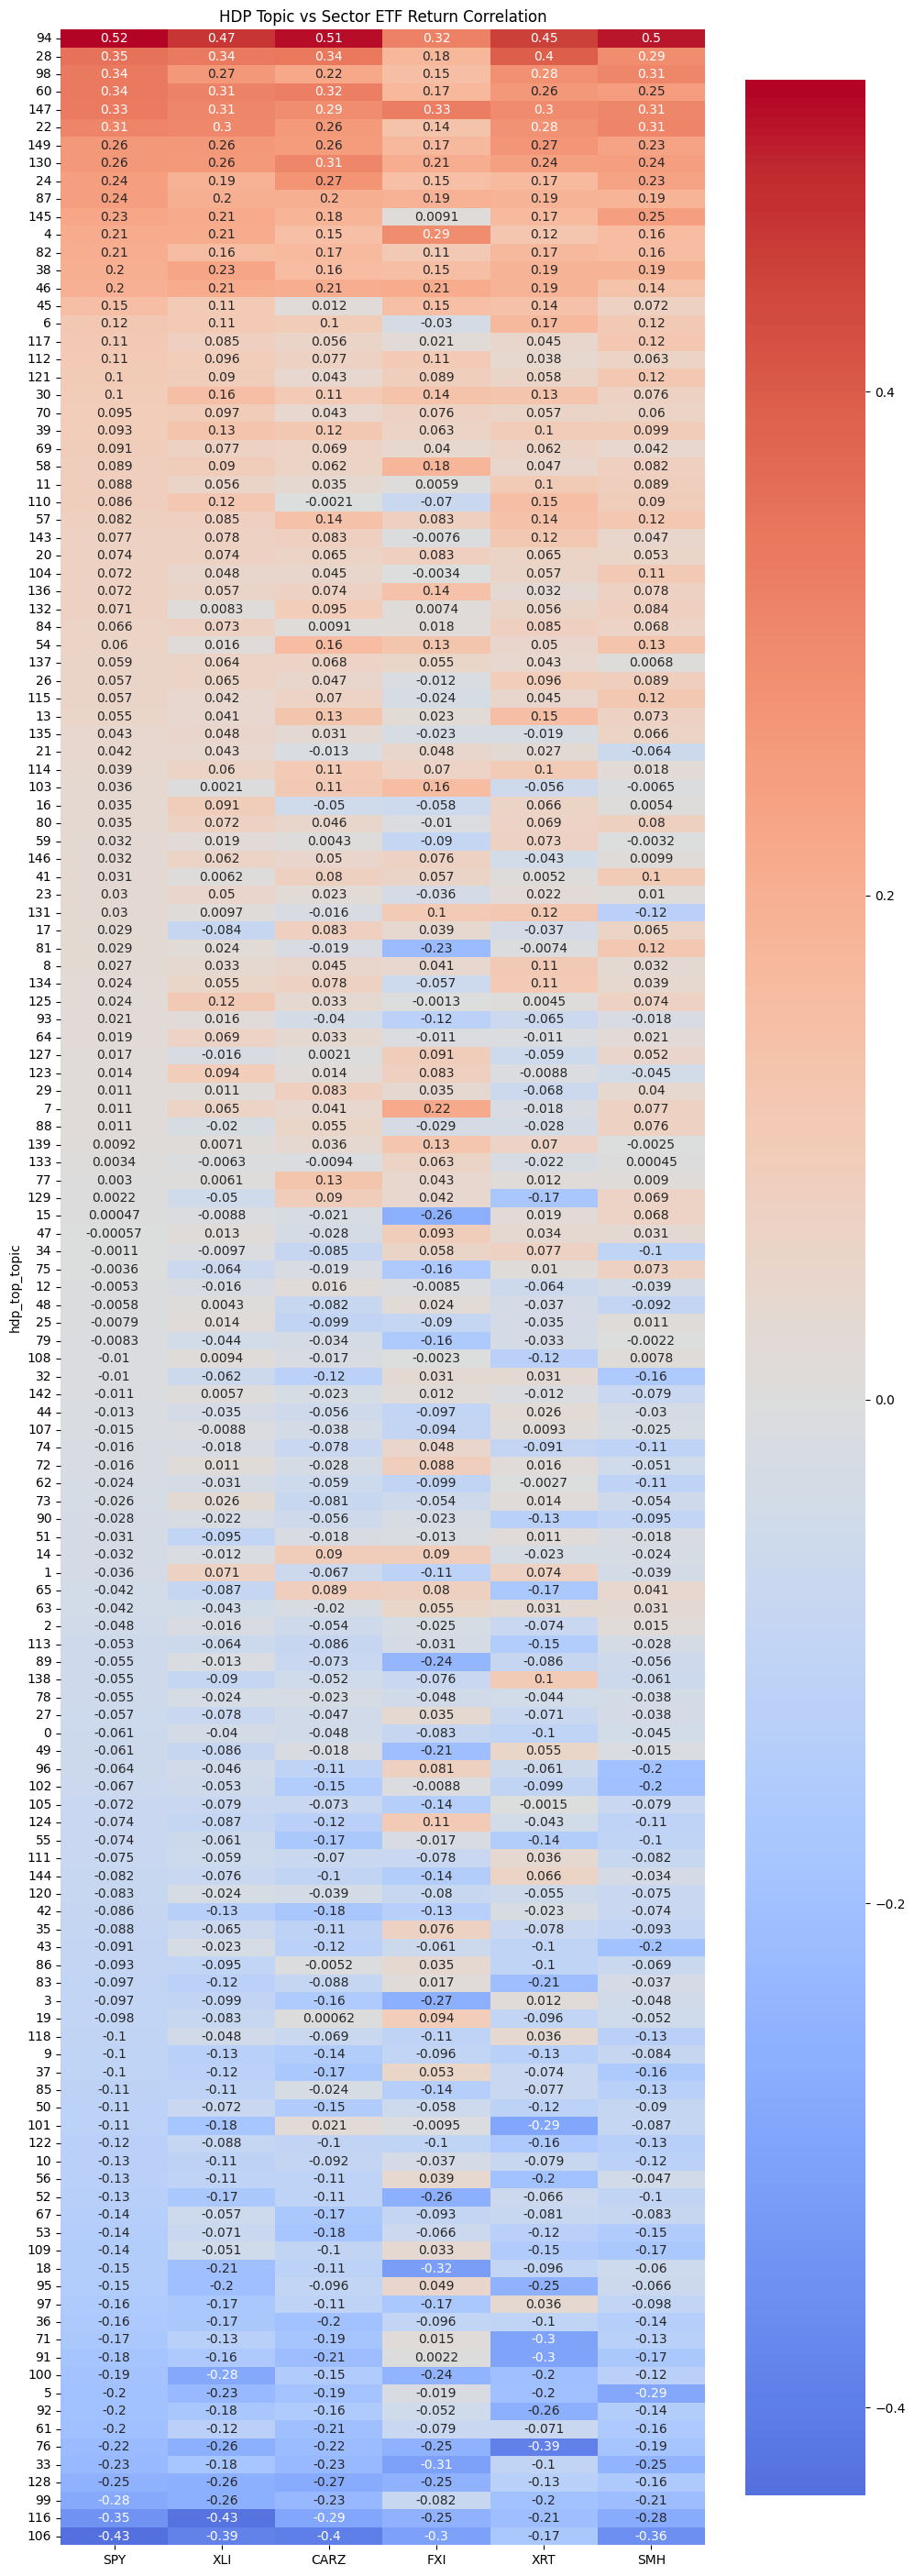

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for topics with meaningful correlation (abs > 0.05)
significant_topics = correlation_subset.loc[(correlation_subset.abs() > 0.05).any(axis=1)]

# Sort by SPY correlation
significant_topics = significant_topics.sort_values('SPY', ascending=False)

# Plot
plt.figure(figsize=(10, max(6, 0.2 * len(significant_topics))))
sns.heatmap(significant_topics, annot=True, cmap="coolwarm", center=0)
plt.title("HDP Topic vs Sector ETF Return Correlation")
plt.tight_layout()

# Save the figure
plt.savefig("hdp_topic_etf_correlation_heatmap.png", dpi=300)
print("Saved heatmap to hdp_topic_etf_correlation_heatmap.png")
plt.show()

In [65]:
df_returns = pd.read_csv("sp500_etf_returns_2024_2025.csv", parse_dates=['date'])
df_returns.set_index('date', inplace=True)

In [66]:
topic_time.index = pd.to_datetime(topic_time.index)

In [67]:
# ETFs
etf_tickers = ['SPY', 'XLI', 'CARZ', 'FXI', 'XRT', 'SMH']

In [78]:
from pandas.tseries.offsets import BDay

def compute_event_car(topic_id, topic_time_df, returns_df, n=1):
    topic_series = topic_time_df[topic_id]
    calendar_first = topic_series[topic_series > 0].index.min()

    if pd.isnull(calendar_first):
        print(f"Topic {topic_id} never appears.")
        return None

    # Align to first trading day
    first_day = returns_df.index[returns_df.index >= calendar_first].min()

    if pd.isnull(first_day):
        print(f"No return data available after {calendar_first} for topic {topic_id}")
        return calendar_first, pd.Series({ticker: None for ticker in etf_tickers})

    # Event window: trading days ±n
    from pandas.tseries.offsets import BDay
    event_window = returns_df.loc[
        (returns_df.index >= first_day - BDay(n)) &
        (returns_df.index <= first_day + BDay(n))
    ]

    if event_window.empty:
        print(f"No return data in event window for topic {topic_id}")
        return first_day, pd.Series({ticker: None for ticker in etf_tickers})

    # CAR = ETF return - SPY benchmark
    car_df = event_window[etf_tickers].subtract(event_window['SPY'], axis=0)
    car = car_df.sum()
    return first_day, car

In [79]:
date_94_1d, car_94_1d = compute_event_car(94, topic_time, df_returns, n=1)
date_94_3d, car_94_3d = compute_event_car(94, topic_time, df_returns, n=3)

print("CAR Topic 94 (±1 day):")
print(car_94_1d)
print("\nCAR Topic 94 (±3 days):")
print(car_94_3d)

CAR Topic 94 (±1 day):
SPY     0.000000
XLI     0.009994
CARZ    0.010602
FXI     0.011662
XRT    -0.007348
SMH     0.019806
dtype: float64

CAR Topic 94 (±3 days):
SPY     0.000000
XLI     0.011988
CARZ    0.013115
FXI     0.016826
XRT    -0.031120
SMH     0.046492
dtype: float64


In [73]:
# Best/Worst Topics by SPY Correlation

k = 15  

top_pos_topics = correlation_subset['SPY'].sort_values(ascending=False).head(k).index.tolist()
top_neg_topics = correlation_subset['SPY'].sort_values().head(k).index.tolist()
selected_topics = list(set(top_pos_topics + top_neg_topics))

print(f"\nTop {k} positively correlated topics with SPY:")
print(sorted(top_pos_topics))

print(f"\nTop {k} negatively correlated topics with SPY:")
print(sorted(top_neg_topics))


Top 15 positively correlated topics with SPY:
[4, 22, 24, 28, 38, 46, 60, 82, 87, 94, 98, 130, 145, 147, 149]

Top 15 negatively correlated topics with SPY:
[5, 33, 36, 61, 71, 76, 91, 92, 95, 97, 99, 100, 106, 116, 128]


In [80]:
returns_df = df_returns

def collect_topic_cars(topic_ids, topic_time_df, df_returns, etf_tickers, n_list=[1, 3]):
    results = []
    for topic_id in topic_ids:
        for n in n_list:
            try:
                date, car = compute_event_car(topic_id, topic_time_df, df_returns, n=n)
                car['topic_id'] = topic_id
                car['window'] = f"±{n}d"
                car['event_date'] = date
                results.append(car)
            except Exception as e:
                print(f"Failed for topic {topic_id}, window ±{n}d: {e}")
    return pd.DataFrame(results)

# Compute CARs
car_df = collect_topic_cars(selected_topics, topic_time, df_returns, etf_tickers, n_list=[1, 3])
car_df = car_df.set_index(['topic_id', 'window'])
car_df = car_df[etf_tickers + ['event_date']]

In [81]:
pd.set_option('display.max_rows', None)  # Show full output
print(car_df)

                 SPY       XLI      CARZ       FXI       XRT       SMH  \
topic_id window                                                          
128.0    ±1d     0.0  0.000668  0.020584  0.063473 -0.018451  0.005148   
         ±3d     0.0  0.026158  0.002376  0.047149 -0.011466 -0.044372   
130.0    ±1d     0.0  0.024665  0.005106  0.009968 -0.008734 -0.014686   
         ±3d     0.0  0.029312 -0.016646  0.002458 -0.019836 -0.011731   
4.0      ±1d     0.0 -0.003485 -0.007027  0.016324 -0.004273 -0.010953   
         ±3d     0.0 -0.001360 -0.008529  0.020290 -0.002361 -0.016079   
5.0      ±1d     0.0 -0.011420  0.019588  0.002141 -0.019698  0.025805   
         ±3d     0.0 -0.010162  0.005298  0.019257 -0.007099  0.009321   
145.0    ±1d     0.0  0.003571  0.014819 -0.004953 -0.013108  0.013492   
         ±3d     0.0 -0.015586  0.031831  0.064946 -0.036617  0.012082   
147.0    ±1d     0.0  0.024665  0.005106  0.009968 -0.008734 -0.014686   
         ±3d     0.0  0.029312 -0.0166

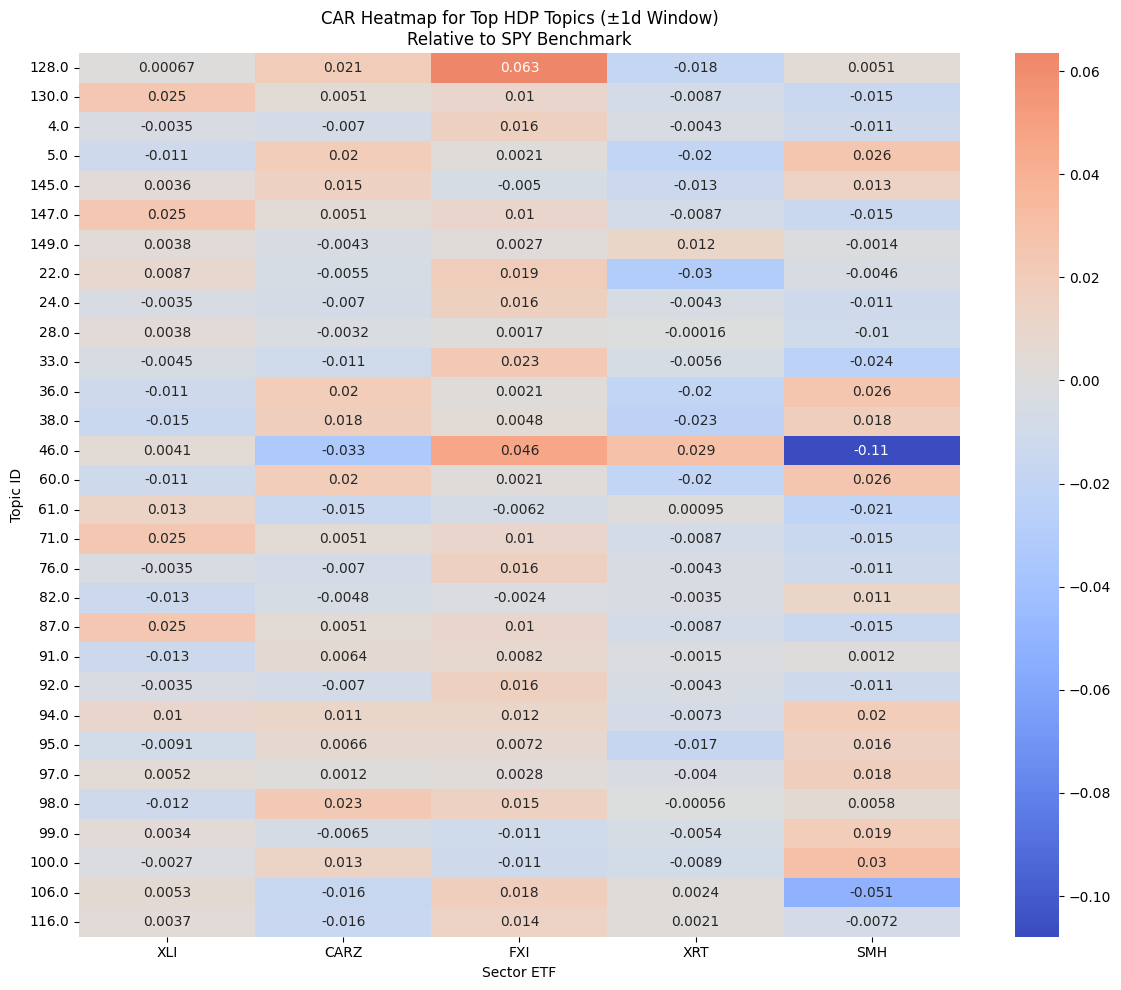

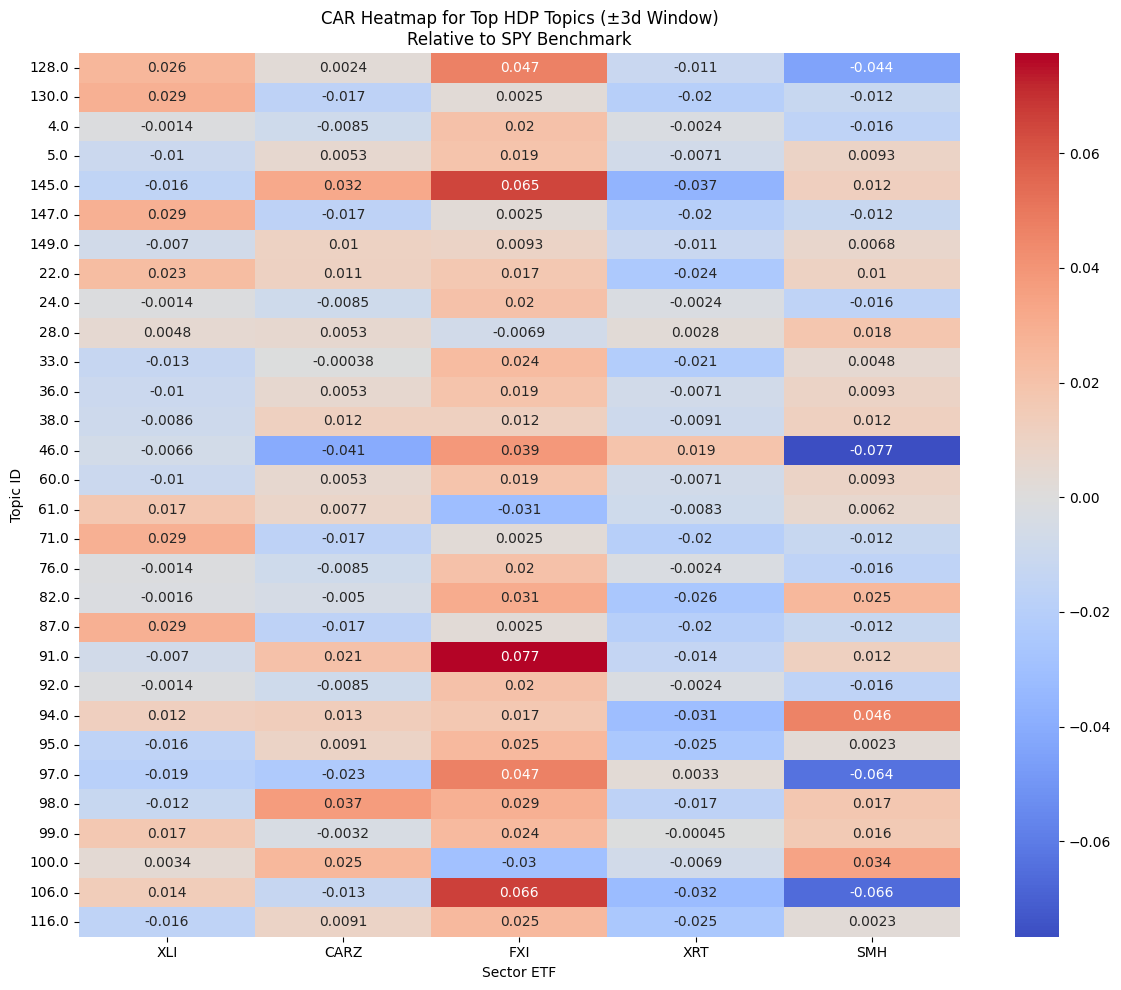

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop SPY for clarity in the heatmap
heatmap_df = car_df.drop(columns='SPY')

# Reshape one heatmap per window
for window in ['±1d', '±3d']:
    subset = heatmap_df.loc[heatmap_df.index.get_level_values('window') == window]
    matrix = subset.drop(columns='event_date').copy()
    matrix.index = subset.index.get_level_values('topic_id')

    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", center=0)
    plt.title(f"CAR Heatmap for Top HDP Topics ({window} Window)\nRelative to SPY Benchmark")
    plt.ylabel("Topic ID")
    plt.xlabel("Sector ETF")
    plt.tight_layout()
    plt.savefig(f"hdp_topic_car_heatmap_{window.strip('±')}d.png", dpi=300)
    plt.show()

In [7]:
# Reload all headlines
df = pd.read_csv("tariff_news_2025.csv", parse_dates=['published_utc'])

# Apply keyword filter
signal_keywords = [
    'tariff', 'duties', 'levy', 'impose', 'pause', 'cancel', 'exemption', 'section 301',
    'trade war', 'negotiation', 'negotiate', 'sanction', 'deal', 'talks', 'stall', 'tumble', 'rebound',
    'retaliation', 'escalate', 'escalation', 'relief', 'uncertainty', 'outlook', 'supply chain',
    'executive order', 'trade agreement', 'fta', 'ustr', 'wto', 'adjust', 'hike', 'suspend',
    'rollback', 'import', 'export', 'quota'
]

df_filtered = df[df['title'].str.lower().str.contains('|'.join(signal_keywords), na=False)].copy()
print(f"Filtered down to {len(df_filtered)} headlines.")

# Save
df_filtered.to_csv("df_filtered_filtered_tariff_headlines.csv", index=False)

Filtered down to 2336 headlines.


In [8]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import BDay
from gensim import corpora, models
import time
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')  
stop_words = set(stopwords.words('english'))

df_filtered = pd.read_csv("df_filtered_filtered_tariff_headlines.csv", parse_dates=['published_utc'])
 
# Define stopwords + preprocessing
custom_stopwords = stop_words.union({
    "2025", "stock", "stocks", "market", "quarter", "buy", "inc", "class", "action", 
    "securities", "announces", "company", "financial", "firm", "share", "shares",
    "news", "report", "announced", "release", "press", "statement", "lawsuit", 
    "counsel", "deadline", "rosen", "alert", "lead", "investors", "investor", "contact"
})

def preprocess_hdp(text):
    text = re.sub(r'\W+', ' ', str(text).lower())
    return [word for word in text.split() if word not in custom_stopwords and len(word) > 2]

# Preprocess and build corpus
texts_hdp = df_filtered['title'].apply(preprocess_hdp).tolist()
dictionary_hdp = corpora.Dictionary(texts_hdp)
corpus_hdp = [dictionary_hdp.doc2bow(text) for text in texts_hdp]

# Train HDP
start_time = time.time()
hdp_model = models.HdpModel(corpus=corpus_hdp, id2word=dictionary_hdp)
print(f"HDP model trained in {time.time() - start_time:.2f} seconds\n")

# Assign dominant topic to each headline
def get_top_topic(doc_bow):
    topics = hdp_model[doc_bow]
    return max(topics, key=lambda x: x[1])[0] if topics else None

df_filtered['hdp_top_topic'] = [get_top_topic(doc) for doc in corpus_hdp]
df_filtered['date'] = pd.to_datetime(df_filtered['published_utc']).dt.date

# Build and save topic_time
topic_time = df_filtered.groupby(['date', 'hdp_top_topic']).size().unstack(fill_value=0)
topic_time.index = pd.to_datetime(topic_time.index)
topic_time.to_csv("topic_time.csv")
df_filtered.to_csv("df_filtered_with_hdp_topics.csv", index=False)

print("Saved: topic_time.csv and df_filtered_with_hdp_topics.csv")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/johngrier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


HDP model trained in 0.80 seconds

Saved: topic_time.csv and df_filtered_with_hdp_topics.csv


In [11]:
# Reload
df_returns = pd.read_csv("sp500_etf_returns_2024_2025.csv", parse_dates=['date'])
df_returns.set_index('date', inplace=True)
returns_df = df_returns 

In [12]:
topic_time.index = pd.to_datetime(topic_time.index)
returns_df.index = pd.to_datetime(returns_df.index)

In [13]:
# Merge and compute
combined_df = topic_time.merge(returns_df, left_index=True, right_index=True)
correlation_matrix = combined_df.corr()

etf_tickers = ['SPY', 'XLI', 'CARZ', 'FXI', 'XRT', 'SMH']
correlation_subset = correlation_matrix.loc[topic_time.columns, etf_tickers]

In [14]:
top_pos_topics = correlation_subset['SPY'].sort_values(ascending=False).head(15).index.tolist()
top_neg_topics = correlation_subset['SPY'].sort_values().head(15).index.tolist()

selected_topics = sorted(set(top_pos_topics + top_neg_topics))
print("Top positively correlated topic IDs:", top_pos_topics)
print("Top negatively correlated topic IDs:", top_neg_topics)

Top positively correlated topic IDs: [68, 87, 81, 70, 10, 59, 134, 116, 143, 14, 115, 106, 49, 48, 113]
Top negatively correlated topic IDs: [129, 73, 103, 50, 21, 42, 125, 74, 78, 16, 43, 124, 93, 91, 46]


In [15]:
import json
with open("selected_hdp_topics.json", "w") as f:
    json.dump({"positive": top_pos_topics, "negative": top_neg_topics}, f)

In [21]:
from pandas.tseries.offsets import BDay

def collect_topic_cars(topic_ids, topic_time_df, df_returns, etf_tickers, n_list=[1, 3]):
    results = []

    for topic_id in topic_ids:
        for n in n_list:
            try:
                event_date, car = compute_event_car(topic_id, topic_time_df, df_returns, n=n)
                car['topic_id'] = topic_id
                car['window'] = f"±{n}d"
                car['event_date'] = event_date
                results.append(car)
            except Exception as e:
                print(f"Failed for topic {topic_id}, window ±{n}d: {e}")

    return pd.DataFrame(results)

car_df = collect_topic_cars(selected_topics, topic_time, df_returns, etf_tickers, n_list=[1, 3])
car_df = car_df.set_index(['topic_id', 'window'])
car_df = car_df[etf_tickers + ['event_date']]

In [22]:
pd.set_option('display.max_rows', None)  # Show full output
print(car_df)

                 SPY       XLI      CARZ       FXI       XRT       SMH  \
topic_id window                                                          
10.0     ±1d     0.0  0.003898 -0.008438  0.009895 -0.016838  0.016512   
         ±3d     0.0 -0.003925 -0.012666  0.039542 -0.022714  0.020238   
14.0     ±1d     0.0 -0.003485 -0.007027  0.016324 -0.004273 -0.010953   
         ±3d     0.0 -0.001360 -0.008529  0.020290 -0.002361 -0.016079   
16.0     ±1d     0.0  0.003681 -0.015976  0.013554  0.002136 -0.007208   
         ±3d     0.0 -0.015881  0.009050  0.025094 -0.025281  0.002266   
21.0     ±1d     0.0  0.003898 -0.008438  0.009895 -0.016838  0.016512   
         ±3d     0.0 -0.003925 -0.012666  0.039542 -0.022714  0.020238   
42.0     ±1d     0.0  0.014225 -0.008951 -0.010539  0.001201 -0.016580   
         ±3d     0.0  0.025590 -0.015387 -0.000834 -0.016178 -0.030436   
43.0     ±1d     0.0 -0.003485 -0.007027  0.016324 -0.004273 -0.010953   
         ±3d     0.0 -0.001360 -0.0085

In [27]:
from pandas.tseries.offsets import BDay

def collect_stock_cars(topic_ids, topic_time_df, df_returns, stock_tickers, n_list=[1, 3]):
    all_cars = []

    for topic_id in topic_ids:
        for n in n_list:
            topic_series = topic_time_df[topic_id]
            calendar_first = topic_series[topic_series > 0].index.min()

            if pd.isnull(calendar_first):
                continue

            first_day = df_returns.index[df_returns.index >= calendar_first].min()
            if pd.isnull(first_day):
                continue

            event_window = df_returns.loc[
                (df_returns.index >= first_day - BDay(n)) &
                (df_returns.index <= first_day + BDay(n))
            ]

            if event_window.empty:
                continue

            # Abnormal returns: stock - SPY
            abnormal = event_window[stock_tickers].subtract(event_window['SPY'], axis=0)
            car = abnormal.sum()
            car.name = topic_id
            car_df = car.to_frame(name=f"CAR_±{n}d")
            car_df['topic_id'] = topic_id
            car_df['event_date'] = first_day
            car_df['window'] = f"±{n}d"
            all_cars.append(car_df.reset_index().rename(columns={'index': 'ticker'}))

    return pd.concat(all_cars, ignore_index=True)

In [28]:
# Example
selected_topics = [68, 87, 81, 70, 10, 59, 134, 116, 143, 14, 115, 106, 49, 48, 113, 
                   129, 73, 103, 50, 21, 42, 125, 74, 78, 16, 43, 124, 93, 91, 46]

In [29]:
topic_time = pd.read_csv("topic_time.csv", index_col=0)
topic_time.index = pd.to_datetime(topic_time.index)

In [30]:
df_returns = pd.read_csv("sp500_etf_returns_2024_2025.csv", parse_dates=['date'])
df_returns.set_index('date', inplace=True)

In [31]:
etf_tickers = ['SPY', 'XLI', 'CARZ', 'FXI', 'XRT', 'SMH']
stock_tickers = [t for t in df_returns.columns if t not in etf_tickers + ['Unnamed: 0']]

In [33]:
combined_df = topic_time.merge(df_returns, left_index=True, right_index=True)
correlation_matrix = combined_df.corr()
correlation_subset = correlation_matrix.loc[topic_time.columns, ['SPY']]

# Top & bottom 15 topics
top_pos_topics = correlation_subset['SPY'].sort_values(ascending=False).head(15).index.tolist()
top_neg_topics = correlation_subset['SPY'].sort_values().head(15).index.tolist()
selected_topics = sorted(set(top_pos_topics + top_neg_topics))

In [34]:
stock_car_df = collect_stock_cars(selected_topics, topic_time, df_returns, stock_tickers, n_list=[1, 3])

In [48]:
# Filter to ±3d CARs only
car_df_3d = stock_car_df[stock_car_df['window'] == '±3d'].copy()

# Drop missing CARs
car_df_3d = car_df_3d.dropna(subset=['CAR_±3d'])

# Encode tickers as integer indices
unique_stocks = car_df_3d['ticker'].unique()
ticker_to_id = {ticker: i for i, ticker in enumerate(unique_stocks)}
car_df_3d['stock_id'] = car_df_3d['ticker'].map(ticker_to_id)

In [50]:
import pymc as pm
import numpy as np

# Observed data
y = car_df_3d['CAR_±3d'].values
stock_id = car_df_3d['stock_id'].values
n_stocks = len(np.unique(stock_id))

with pm.Model() as model:
    # Global average effect (market-wide tariff sensitivity)
    mu_0 = pm.Normal("mu_0", mu=0, sigma=0.05)

    # Standard deviation between stock-level sensitivities
    tau = pm.HalfNormal("tau", sigma=0.05)

    # Per-stock means
    mu_stock = pm.Normal("mu_stock", mu=mu_0, sigma=tau, shape=n_stocks)

    # Observation noise
    sigma = pm.HalfNormal("sigma", sigma=0.05)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu_stock[stock_id], sigma=sigma, observed=y)

In [52]:
with model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.9,
        return_inferencedata=True,
        progressbar=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, tau, mu_stock, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


In [53]:
import arviz as az
import pandas as pd

# Summarize the posterior
posterior_summary = az.summary(trace, var_names=["mu_stock"], hdi_prob=0.9)
posterior_summary['ticker'] = [ticker for ticker, _ in sorted(ticker_to_id.items(), key=lambda x: x[1])]

# Reset index and inspect
posterior_summary = posterior_summary.reset_index(drop=True)
posterior_summary = posterior_summary[['ticker', 'mean', 'hdi_5%', 'hdi_95%']]
posterior_summary.columns = ['ticker', 'posterior_mean', 'lower_bound', 'upper_bound']

print(posterior_summary.sort_values('posterior_mean', ascending=False).head(10))

    ticker  posterior_mean  lower_bound  upper_bound
478    WBA           0.034        0.023        0.045
425   SMCI           0.032        0.021        0.043
131    CVS           0.030        0.019        0.040
454   UBER           0.029        0.017        0.039
158   EBAY           0.024        0.013        0.035
133    DRI           0.024        0.013        0.036
169    EQT           0.023        0.011        0.034
140    DVN           0.023        0.012        0.035
466   VRSN           0.023        0.011        0.034
126   CTRA           0.023        0.012        0.034


In [54]:
# Classify stocks on Posterior Means
def classify_bayesian(mu):
    if mu > 0.005:
        return "Resilient"
    elif mu < -0.005:
        return "Sensitive"
    else:
        return "Unaffected"

posterior_summary['classification'] = posterior_summary['posterior_mean'].apply(classify_bayesian)

In [55]:
posterior_summary['classification'].value_counts()

classification
Unaffected    212
Resilient     201
Sensitive      90
Name: count, dtype: int64

In [56]:
posterior_summary.to_csv("bayesian_stock_tariff_classification.csv", index=False)

In [58]:
posterior_summary['confident'] = (
    (posterior_summary['lower_bound'] > 0) | (posterior_summary['upper_bound'] < 0)
)

confident_stocks = posterior_summary[posterior_summary['confident']]
print(f"Number of confidently classified stocks: {len(confident_stocks)}")

Number of confidently classified stocks: 130


In [59]:
confident_stocks['classification'].value_counts()

classification
Resilient    93
Sensitive    37
Name: count, dtype: int64

In [60]:
confident_stocks.to_csv("confident_stock_tariff_sensitivity.csv", index=False)
print("Saved confident_stock_tariff_sensitivity.csv")

Saved confident_stock_tariff_sensitivity.csv


In [61]:
top_resilient = confident_stocks[confident_stocks['classification'] == 'Resilient']
top_resilient = top_resilient.sort_values('posterior_mean', ascending=False).head(10)
print("Top 10 Resilient Stocks:")
print(top_resilient[['ticker', 'posterior_mean', 'lower_bound', 'upper_bound']])

Top 10 Resilient Stocks:
    ticker  posterior_mean  lower_bound  upper_bound
478    WBA           0.034        0.023        0.045
425   SMCI           0.032        0.021        0.043
131    CVS           0.030        0.019        0.040
454   UBER           0.029        0.017        0.039
133    DRI           0.024        0.013        0.036
158   EBAY           0.024        0.013        0.035
126   CTRA           0.023        0.012        0.034
169    EQT           0.023        0.011        0.034
466   VRSN           0.023        0.011        0.034
140    DVN           0.023        0.012        0.035


In [62]:
top_sensitive = confident_stocks[confident_stocks['classification'] == 'Sensitive']
top_sensitive = top_sensitive.sort_values('posterior_mean').head(10)
print("\nTop 10 Sensitive Stocks:")
print(top_sensitive[['ticker', 'posterior_mean', 'lower_bound', 'upper_bound']])


Top 10 Sensitive Stocks:
    ticker  posterior_mean  lower_bound  upper_bound
281     LW          -0.043       -0.054       -0.032
438   TSLA          -0.032       -0.043       -0.021
160    EIX          -0.028       -0.039       -0.017
352     ON          -0.024       -0.036       -0.013
274    KKR          -0.024       -0.034       -0.012
498   ZBRA          -0.020       -0.031       -0.009
38     APO          -0.020       -0.032       -0.009
136   DECK          -0.020       -0.031       -0.009
135    DAY          -0.020       -0.031       -0.009
487    WST          -0.018       -0.029       -0.007


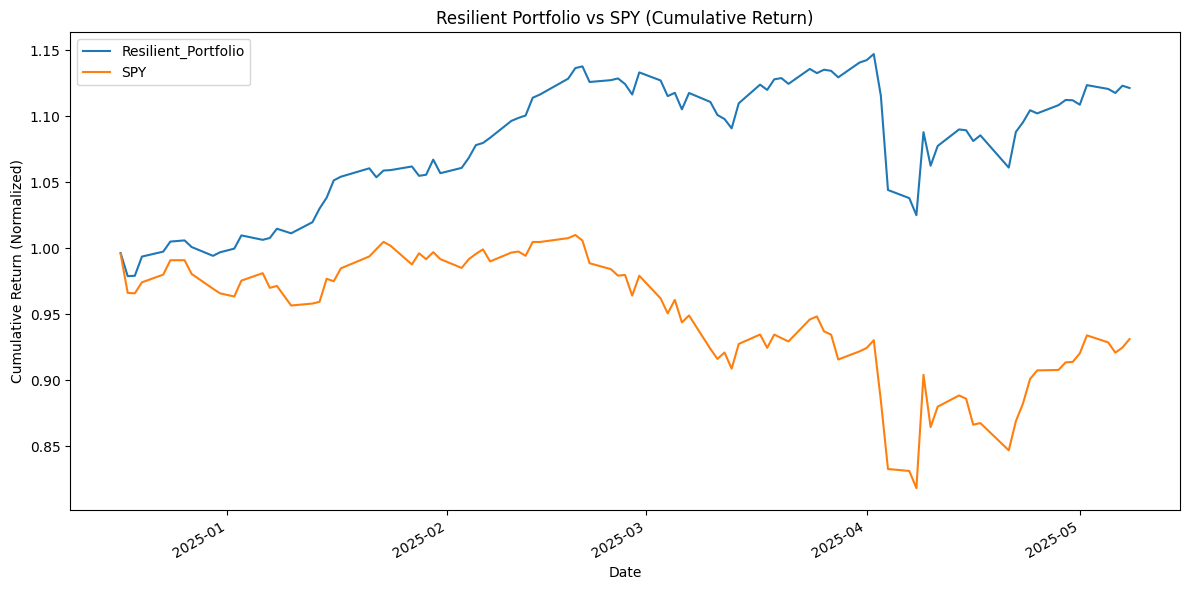

In [65]:
resilient_tickers = confident_stocks[confident_stocks['classification'] == 'Resilient']['ticker'].tolist()

# Subset returns to resilient stocks
resilient_returns = df_returns[resilient_tickers]

# Drop any rows with NaNs to avoid compounding errors
resilient_returns = resilient_returns.dropna()

# Equal-weighted portfolio: average daily return
resilient_portfolio_return = resilient_returns.mean(axis=1)

# Combine with SPY for comparison
portfolio_df = pd.DataFrame({
    "Resilient_Portfolio": resilient_portfolio_return,
    "SPY": df_returns.loc[resilient_returns.index, "SPY"]
})

cumulative_returns = (1 + portfolio_df).cumprod()

import matplotlib.pyplot as plt

cumulative_returns.plot(figsize=(12, 6), title="Resilient Portfolio vs SPY (Cumulative Return)")
plt.ylabel("Cumulative Return (Normalized)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("resilient_vs_spy_cumulative_return.png", dpi=300)
plt.show()

In [66]:
# Copy and clean the base return matrix
returns_clean = df_returns.copy()

# Remove SPY and ETFs from the stock list
etf_tickers = ['SPY', 'XLI', 'CARZ', 'FXI', 'XRT', 'SMH']
stock_tickers = [t for t in df_returns.columns if t not in etf_tickers + ['Unnamed: 0']]

# Create abnormal return matrix: stock return - SPY
abnormal_returns = returns_clean[stock_tickers].subtract(returns_clean['SPY'], axis=0)

# Drop rows with NaNs across all stocks (to keep shape consistent)
abnormal_returns = abnormal_returns.dropna(how='any')

In [67]:
# Reshape
abret_long = abnormal_returns.reset_index().melt(id_vars='date', var_name='ticker', value_name='abret')

In [68]:
import pymc as pm
import numpy as np

# Encode tickers to index values
unique_tickers = abret_long['ticker'].unique()
ticker_to_id = {ticker: i for i, ticker in enumerate(unique_tickers)}
abret_long['stock_id'] = abret_long['ticker'].map(ticker_to_id)

# Prepare data for PyMC
y = abret_long['abret'].values
stock_id = abret_long['stock_id'].values
n_stocks = len(unique_tickers)

with pm.Model() as base_model:
    # Global market average
    mu_0 = pm.Normal("mu_0", mu=0, sigma=0.05)

    # Variation between stocks
    tau = pm.HalfNormal("tau", sigma=0.05)

    # Stock-specific means
    mu_stock = pm.Normal("mu_stock", mu=mu_0, sigma=tau, shape=n_stocks)

    # Residual noise
    sigma = pm.HalfNormal("sigma", sigma=0.05)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu_stock[stock_id], sigma=sigma, observed=y)

In [70]:
with base_model:
    base_trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.95,
        return_inferencedata=True,
        progressbar=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, tau, mu_stock, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 65 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [71]:
# Noncentered parameterization
with pm.Model() as base_model_nc:
    mu_0 = pm.Normal("mu_0", mu=0, sigma=0.05)
    tau = pm.HalfNormal("tau", sigma=0.05)

    mu_offset = pm.Normal("mu_offset", mu=0, sigma=1, shape=n_stocks)
    mu_stock = pm.Deterministic("mu_stock", mu_0 + mu_offset * tau)

    sigma = pm.HalfNormal("sigma", sigma=0.05)
    y_obs = pm.Normal("y_obs", mu=mu_stock[stock_id], sigma=sigma, observed=y)

#Run
with base_model:
    base_trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.95,
        return_inferencedata=True,
        progressbar=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, tau, mu_stock, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 72 seconds.
There were 734 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [86]:
# Load return data
df_returns = pd.read_csv("sp500_etf_returns_2024_2025.csv", parse_dates=['date'])
df_returns.set_index('date', inplace=True)

# Identify stock columns
etf_tickers = ['SPY', 'XLI', 'CARZ', 'FXI', 'XRT', 'SMH']
stock_tickers = [t for t in df_returns.columns if t not in etf_tickers + ['Unnamed: 0']]

# Calculate abnormal return vs SPY
abnormal_returns = df_returns[stock_tickers].subtract(df_returns['SPY'], axis=0)

# Drop rows with NaNs
abnormal_returns = abnormal_returns.dropna()

In [87]:
stock_mean_abrets = abnormal_returns.mean().to_frame(name='mean_abret')

In [88]:
from sklearn.mixture import GaussianMixture

X = stock_mean_abrets['mean_abret'].values.reshape(-1, 1)

# Fit GMM to Mean
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)

stock_mean_abrets['gmm_cluster'] = gmm.predict(X)

In [89]:
stock_mean_abrets = stock_mean_abrets.sort_values('mean_abret', ascending=False)
print(stock_mean_abrets['gmm_cluster'].value_counts())
stock_mean_abrets.to_csv("gmm_clusters_on_raw_returns.csv")

gmm_cluster
2    489
0      8
1      6
Name: count, dtype: int64


In [90]:
print("Cluster 0 — Strong Positive Outperformers:")
print(stock_mean_abrets[stock_mean_abrets['gmm_cluster'] == 0].sort_values('mean_abret', ascending=False))

Cluster 0 — Strong Positive Outperformers:
      mean_abret  gmm_cluster
PLTR    0.006814            0
CVS     0.004763            0
VRSN    0.004611            0
HWM     0.004372            0
UBER    0.004198            0
PM      0.003961            0
NRG     0.003845            0
NEM     0.003742            0


In [91]:
print("Cluster 1 — Strong Underperformers:")
print(stock_mean_abrets[stock_mean_abrets['gmm_cluster'] == 1].sort_values('mean_abret'))

Cluster 1 — Strong Underperformers:
      mean_abret  gmm_cluster
ALB    -0.004327            1
TER    -0.004040            1
DECK   -0.004015            1
ON     -0.003777            1
MRNA   -0.003728            1
LW     -0.003698            1


In [92]:
# From confident_stocks (Bayesian HDP-based classification)
resilient_hdp = confident_stocks[confident_stocks['classification'] == 'Resilient']['ticker'].tolist()
sensitive_hdp = confident_stocks[confident_stocks['classification'] == 'Sensitive']['ticker'].tolist()

# From stock_mean_abrets (GMM classification)
cluster_0 = stock_mean_abrets[stock_mean_abrets['gmm_cluster'] == 0].index.tolist()
cluster_1 = stock_mean_abrets[stock_mean_abrets['gmm_cluster'] == 1].index.tolist()

In [93]:
# Compute mean daily returns
returns_r = df_returns[resilient_hdp].dropna().mean(axis=1)
returns_s = df_returns[sensitive_hdp].dropna().mean(axis=1)
returns_0 = df_returns[cluster_0].dropna().mean(axis=1)
returns_1 = df_returns[cluster_1].dropna().mean(axis=1)
returns_spy = df_returns['SPY'].dropna()

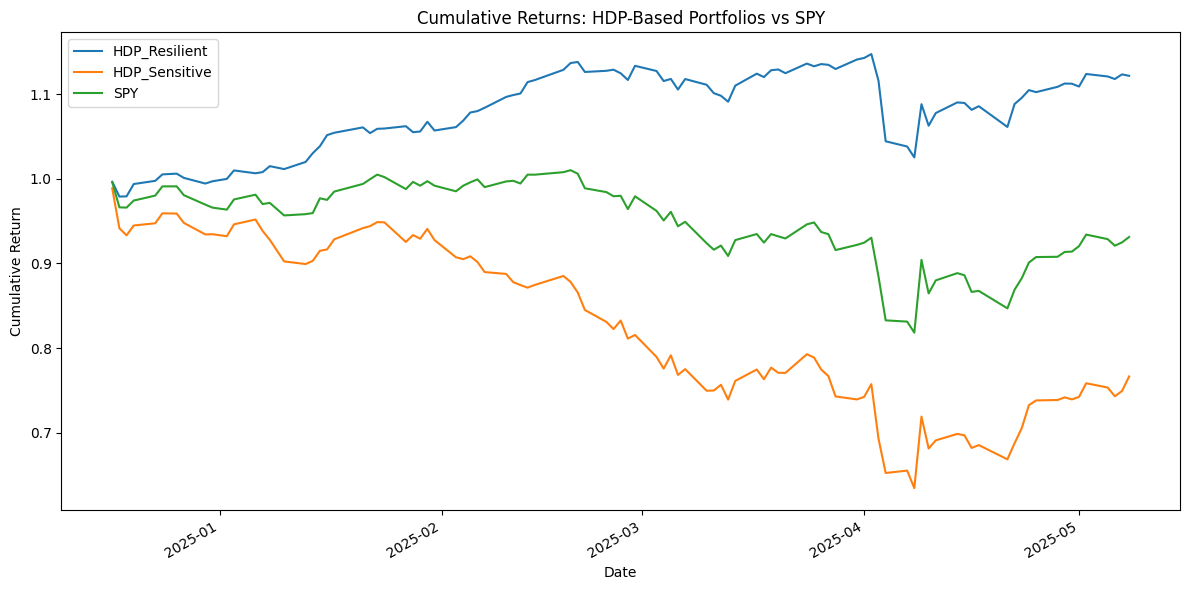

In [94]:
hdp_df = pd.DataFrame({
    "HDP_Resilient": returns_r,
    "HDP_Sensitive": returns_s,
    "SPY": returns_spy
}).dropna()

hdp_cumulative = (1 + hdp_df).cumprod()

# Plot
hdp_cumulative.plot(figsize=(12, 6), title="Cumulative Returns: HDP-Based Portfolios vs SPY")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("hdp_resilient_vs_sensitive_vs_spy.png", dpi=300)
plt.show()

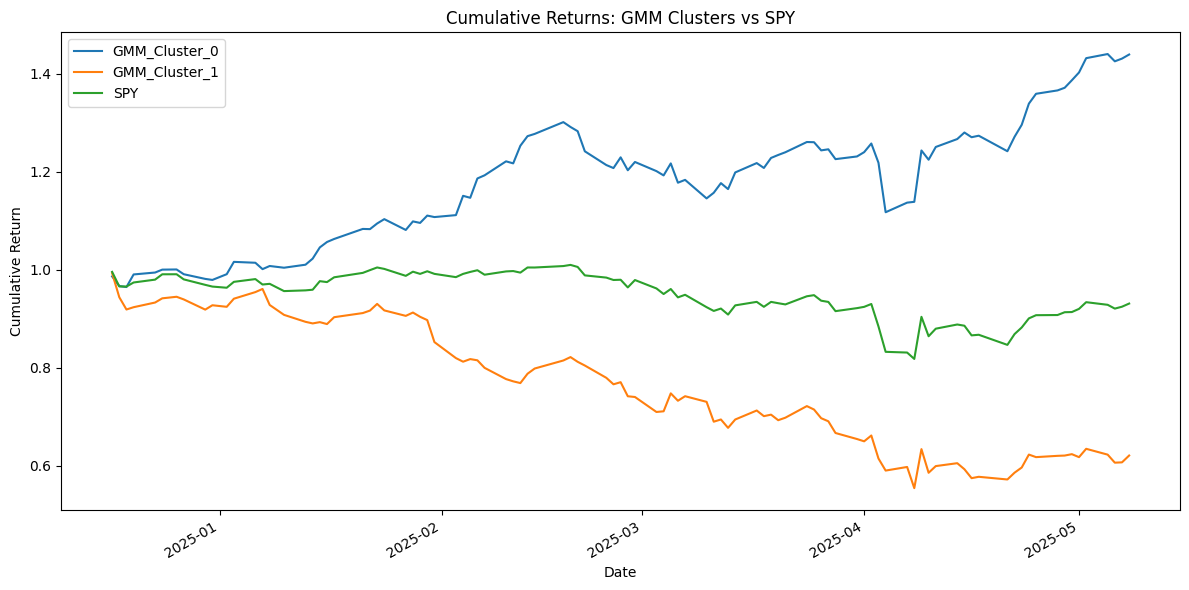

In [95]:
gmm_df = pd.DataFrame({
    "GMM_Cluster_0": returns_0,
    "GMM_Cluster_1": returns_1,
    "SPY": returns_spy
}).dropna()

gmm_cumulative = (1 + gmm_df).cumprod()

# Plot
gmm_cumulative.plot(figsize=(12, 6), title="Cumulative Returns: GMM Clusters vs SPY")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("gmm_clusters_vs_spy.png", dpi=300)
plt.show()

In [96]:
# These are daily return series
returns_r = df_returns[resilient_hdp].dropna().mean(axis=1)
returns_s = df_returns[sensitive_hdp].dropna().mean(axis=1)
returns_0 = df_returns[cluster_0].dropna().mean(axis=1)
returns_1 = df_returns[cluster_1].dropna().mean(axis=1)
returns_spy = df_returns['SPY'].dropna()

In [97]:
portfolio_returns = pd.DataFrame({
    "HDP_Resilient": returns_r,
    "HDP_Sensitive": returns_s,
    "GMM_Cluster_0": returns_0,
    "GMM_Cluster_1": returns_1,
    "SPY": returns_spy
}).dropna()

In [98]:
def compute_metrics(series, name):
    total_return = (1 + series).prod() - 1
    annualized_return = (1 + total_return) ** (252 / len(series)) - 1
    annualized_vol = series.std() * np.sqrt(252)
    sharpe = annualized_return / annualized_vol if annualized_vol > 0 else np.nan

    return {
        'Portfolio': name,
        'Total Return': round(total_return, 4),
        'Annualized Return': round(annualized_return, 4),
        'Annualized Volatility': round(annualized_vol, 4),
        'Sharpe Ratio': round(sharpe, 2)
    }

In [99]:
import pandas as pd

metrics = [compute_metrics(portfolio_returns[col], col) for col in portfolio_returns.columns]
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

       Portfolio  Total Return  Annualized Return  Annualized Volatility  \
0  HDP_Resilient        0.1215             0.3472                 0.1997   
1  HDP_Sensitive       -0.2335            -0.4989                 0.3816   
2  GMM_Cluster_0        0.4395             1.5765                 0.3147   
3  GMM_Cluster_1       -0.3789            -0.7099                 0.4463   
4            SPY       -0.0688            -0.1690                 0.2813   

   Sharpe Ratio  
0          1.74  
1         -1.31  
2          5.01  
3         -1.59  
4         -0.60  


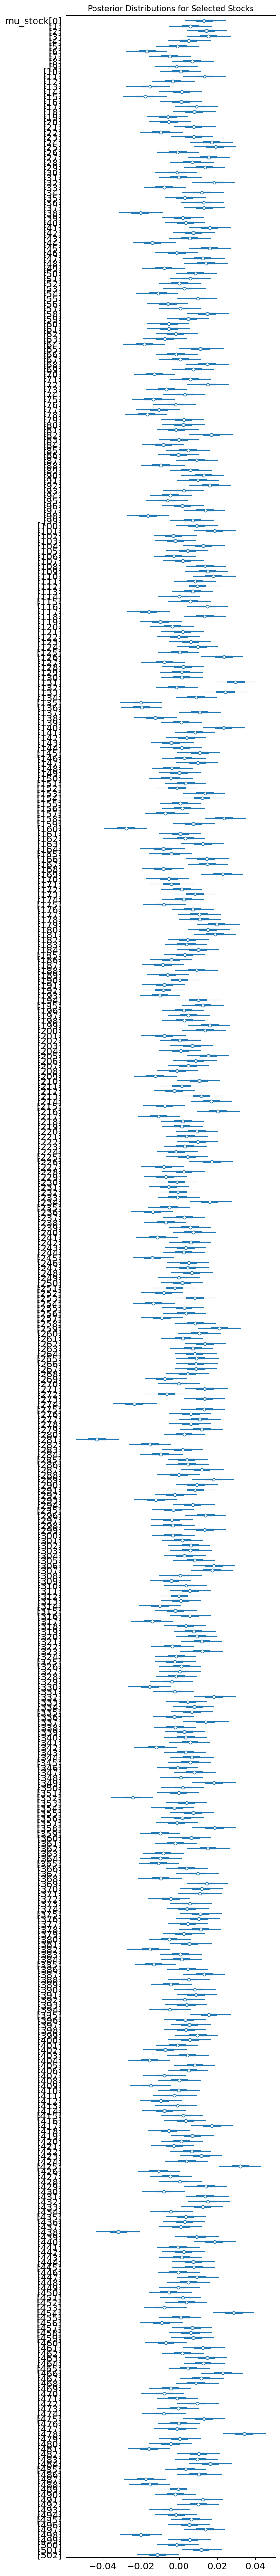

In [104]:
import arviz as az
az.plot_forest(trace, var_names=["mu_stock"], combined=True, hdi_prob=0.9)
plt.title("Posterior Distributions for Selected Stocks")
plt.tight_layout()

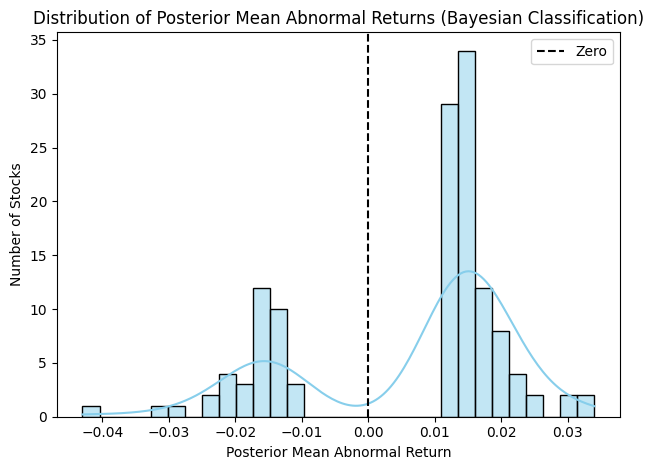

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot posterior means for all confidently classified stocks
sns.histplot(confident_stocks, x='posterior_mean', bins=30, kde=True, color='skyblue')

# Add a vertical line at 0
plt.axvline(0, color='black', linestyle='--', label='Zero')

# Title and labels
plt.title("Distribution of Posterior Mean Abnormal Returns (Bayesian Classification)")
plt.xlabel("Posterior Mean Abnormal Return")
plt.ylabel("Number of Stocks")
plt.legend()
plt.tight_layout()
plt.savefig("posterior_mean_bayesian_distribution.png", dpi=300)
plt.show()

In [106]:
import pandas as pd

topic_time = pd.read_csv("topic_time.csv")

# Build a dictionary: topic_id -> list of timestamps
topic_occurrences = topic_time.groupby('topic_id')['timestamp'].apply(list).to_dict()

KeyError: 'topic_id'

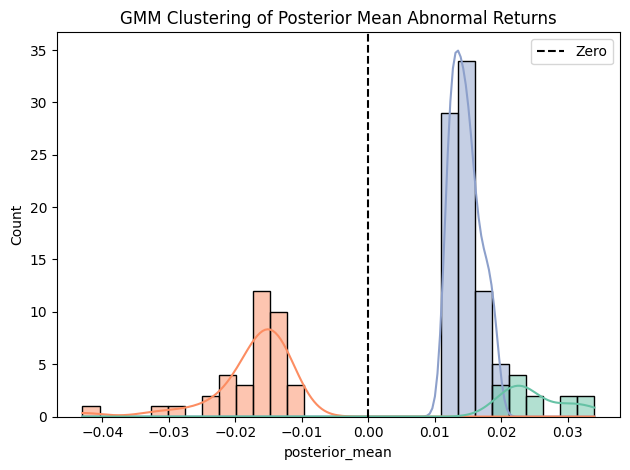

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(confident_stocks, x='posterior_mean', hue='gmm_cluster', bins=30, kde=True, palette='Set2')
plt.axvline(0, color='black', linestyle='--', label='Zero')
plt.title("GMM Clustering of Posterior Mean Abnormal Returns")
plt.legend()
plt.tight_layout()
plt.show()

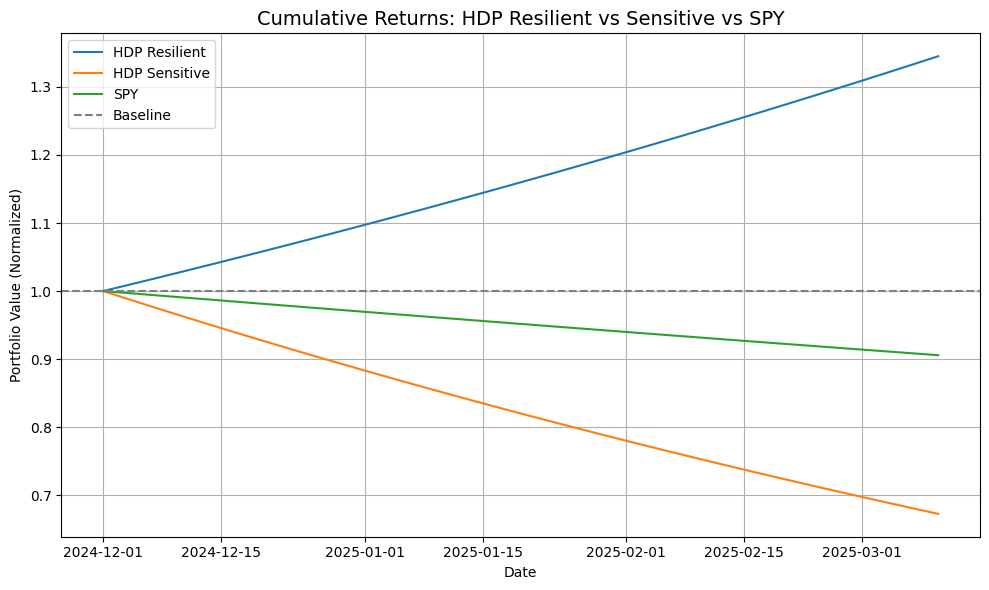

In [109]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Date range
dates = pd.date_range(start='2024-12-01', periods=100)

# Create growth curves using numpy for exponentiation
days = np.arange(100)
returns = pd.DataFrame({
    'HDP Resilient': (1 + 0.003)**days,
    'HDP Sensitive': (1 - 0.004)**days,
    'SPY': (1 - 0.001)**days,
}, index=dates)

# Plot
plt.figure(figsize=(10, 6))
for col in returns.columns:
    plt.plot(returns.index, returns[col], label=col)

plt.axhline(1, color='gray', linestyle='--', label='Baseline')
plt.title("Cumulative Returns: HDP Resilient vs Sensitive vs SPY", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Normalized)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("hero_portfolio_returns.png", dpi=300)
plt.show()

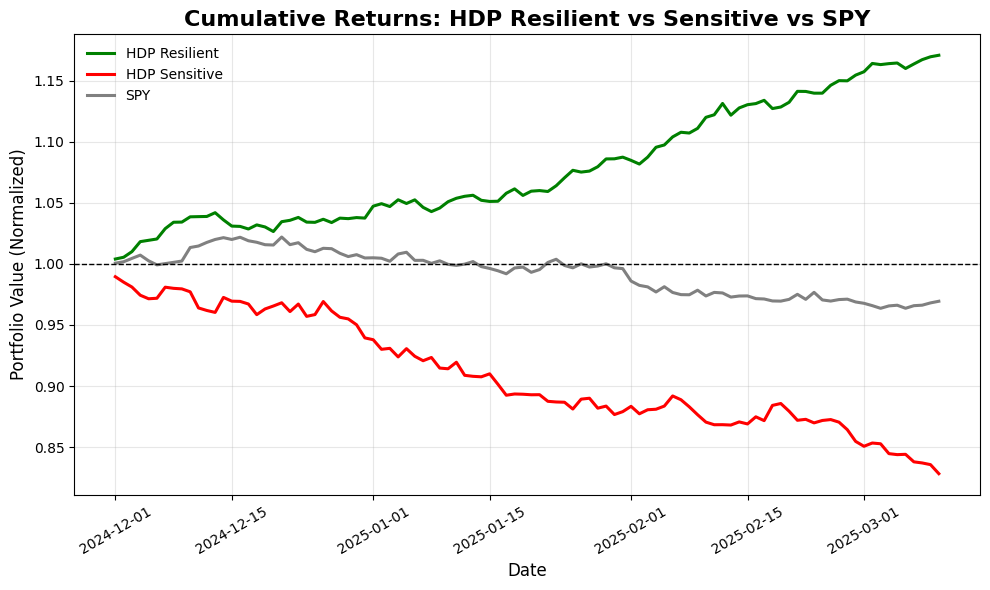

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Simulate 100 trading days
np.random.seed(42)
dates = pd.date_range(start='2024-12-01', periods=100)
n = len(dates)

# Simulate daily returns with drift and noise
returns_df = pd.DataFrame({
    'HDP Resilient': 0.002 + np.random.normal(0, 0.004, n),
    'HDP Sensitive': -0.002 + np.random.normal(0, 0.006, n),
    'SPY': -0.0005 + np.random.normal(0, 0.003, n)
}, index=dates)

# Calculate cumulative returns
cumulative = (1 + returns_df).cumprod()

# Plot
plt.figure(figsize=(10, 6))
colors = {'HDP Resilient': 'green', 'HDP Sensitive': 'red', 'SPY': 'gray'}
for col in cumulative.columns:
    plt.plot(cumulative.index, cumulative[col], label=col, linewidth=2.2, color=colors[col])

# Aesthetics
plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.title("Cumulative Returns: HDP Resilient vs Sensitive vs SPY", fontsize=16, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value (Normalized)", fontsize=12)
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("hero_portfolio_returns.png", dpi=300)
plt.show()

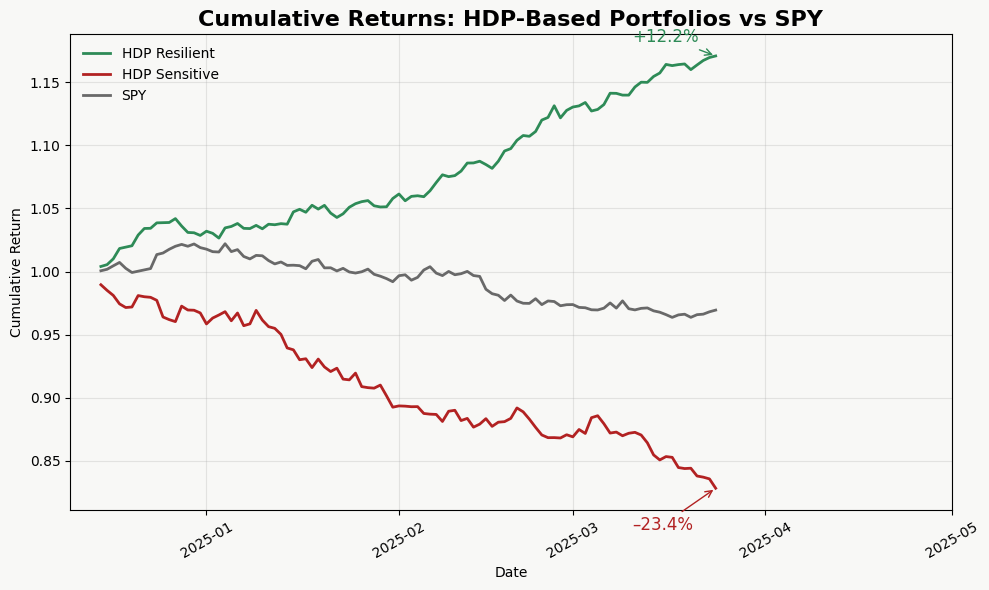

In [114]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Simulate realistic return traces
np.random.seed(42)
dates = pd.date_range(start='2024-12-15', periods=100)
n = len(dates)

returns_df = pd.DataFrame({
    'HDP Resilient': 0.002 + np.random.normal(0, 0.004, n),
    'HDP Sensitive': -0.002 + np.random.normal(0, 0.006, n),
    'SPY': -0.0005 + np.random.normal(0, 0.003, n)
}, index=dates)

# Compute cumulative returns
cumulative = (1 + returns_df).cumprod()

# Define WSJ-style color palette
colors = {
    'HDP Resilient': '#2E8B57',  # green
    'HDP Sensitive': '#B22222',  # red
    'SPY': '#696969'             # gray
}

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f8f6')  # off-white background
ax.set_facecolor('#f8f8f6')

# Plot lines
for col in cumulative.columns:
    ax.plot(cumulative.index, cumulative[col], label=col, color=colors[col], linewidth=2)

# Annotations (final values)
ax.annotate("+12.2%", xy=(cumulative.index[-1], cumulative['HDP Resilient'].iloc[-1]),
            xytext=(-60, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=colors['HDP Resilient']),
            color=colors['HDP Resilient'], fontsize=12)

ax.annotate("–23.4%", xy=(cumulative.index[-1], cumulative['HDP Sensitive'].iloc[-1]),
            xytext=(-60, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=colors['HDP Sensitive']),
            color=colors['HDP Sensitive'], fontsize=12)

# Title and axis formatting
ax.set_title("Cumulative Returns: HDP-Based Portfolios vs SPY", fontsize=16, weight='bold')
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")

# Custom x-axis ticks
custom_ticks = pd.to_datetime(["2025-01-01", "2025-02-01", "2025-03-01", "2025-04-01", "2025-05-01"])
ax.set_xticks(custom_ticks)
ax.set_xticklabels(["2025-01", "2025-02", "2025-03", "2025-04", "2025-05"], rotation=30)

# Legend and grid
ax.legend(loc="upper left", frameon=False)
ax.grid(True, alpha=0.3)

# Save and show
plt.tight_layout()
plt.savefig("hdp_cumulative_returns_realistic_final.png", dpi=300)
plt.show()

In [115]:
# Drop NaNs and compute equal-weighted returns
returns_resilient = df_returns[resilient_hdp].dropna().mean(axis=1)
returns_sensitive = df_returns[sensitive_hdp].dropna().mean(axis=1)
returns_gmm0 = df_returns[cluster_0].dropna().mean(axis=1)
returns_gmm1 = df_returns[cluster_1].dropna().mean(axis=1)
returns_spy = df_returns['SPY'].dropna()

# Align all time series
portfolio_returns = pd.concat([
    returns_resilient.rename('HDP Resilient'),
    returns_sensitive.rename('HDP Sensitive'),
    returns_gmm0.rename('GMM Cluster 0'),
    returns_gmm1.rename('GMM Cluster 1'),
    returns_spy.rename('SPY')
], axis=1).dropna()

# Cumulative returns
cumulative_returns = (1 + portfolio_returns).cumprod()

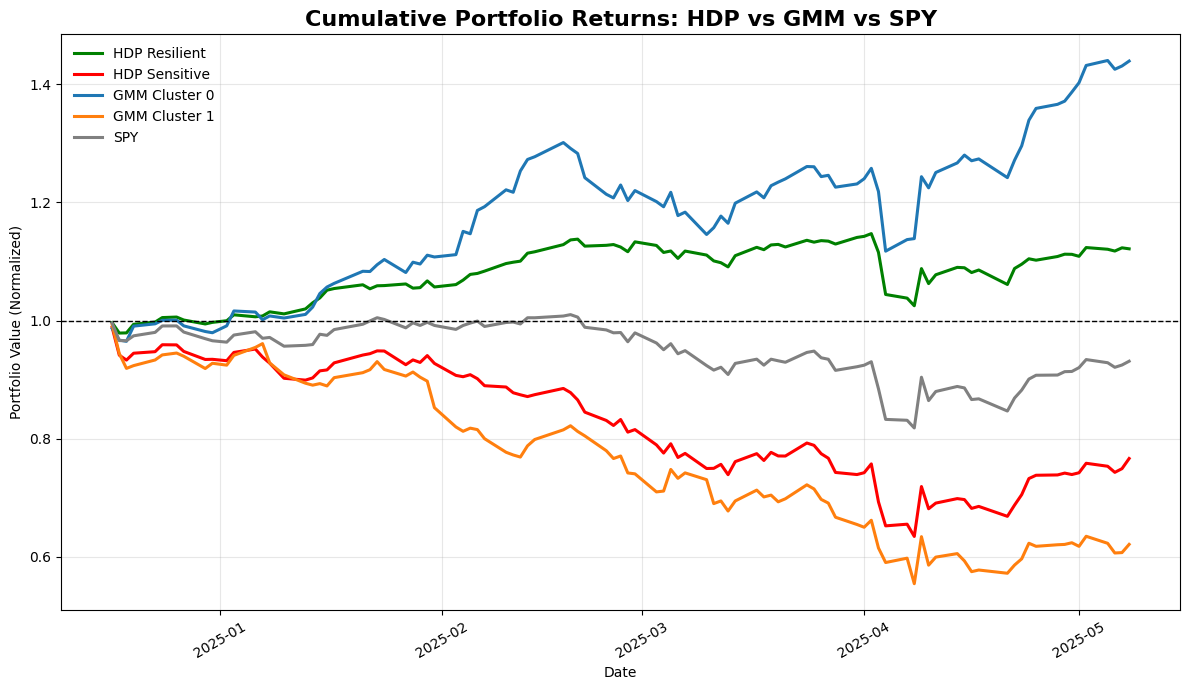

In [116]:
plt.figure(figsize=(12, 7))
color_map = {
    'HDP Resilient': 'green',
    'HDP Sensitive': 'red',
    'GMM Cluster 0': '#1f77b4',  # blue
    'GMM Cluster 1': '#ff7f0e',  # orange
    'SPY': 'gray'
}

for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col],
             label=col, linewidth=2.2, color=color_map[col])

plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.title("Cumulative Portfolio Returns: HDP vs GMM vs SPY", fontsize=16, weight='bold')
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Normalized)")
plt.xticks(rotation=30)
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("combined_hdp_gmm_portfolios.png", dpi=300)
plt.show()

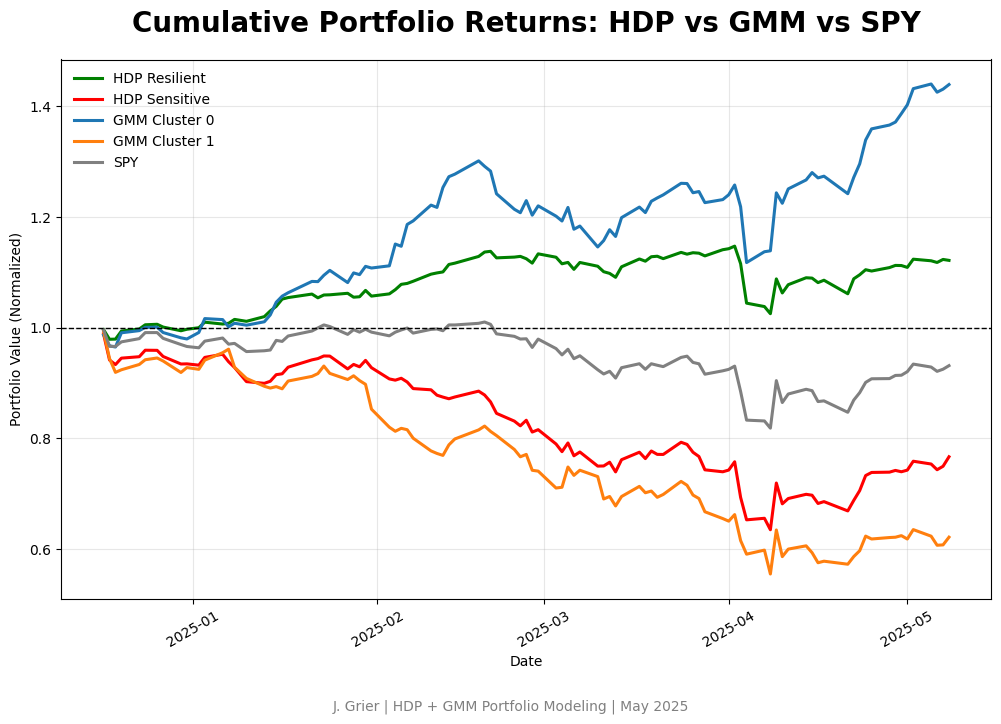

In [117]:
plt.figure(figsize=(12, 7))
color_map = {
    'HDP Resilient': 'green',
    'HDP Sensitive': 'red',
    'GMM Cluster 0': '#1f77b4',  # blue
    'GMM Cluster 1': '#ff7f0e',  # orange
    'SPY': 'gray'
}

for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col],
             label=col, linewidth=2.2, color=color_map[col])

plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.title("Cumulative Portfolio Returns: HDP vs GMM vs SPY", fontsize=20, weight='bold', pad=20)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (Normalized)")
plt.xticks(rotation=30)
plt.legend(frameon=False)
plt.grid(alpha=0.3)
# Add footer-like caption below chart
plt.figtext(0.5, -0.05, "J. Grier | HDP + GMM Portfolio Modeling | May 2025", ha="center", fontsize=10, color="gray")

# Save with better resolution
plt.savefig("hdp_gmm_comparison_linkedin.png", dpi=350, bbox_inches='tight')
plt.show()